In [1]:
# ============================================
# 0) Setup — imports & seeds (no pip on Kaggle)
# ============================================
import os, sys, math, time, subprocess, warnings
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

def _optional_psutil():
    try:
        import psutil
        return psutil
    except Exception:
        return None

psutil = _optional_psutil()  # None if unavailable; ResourceUsageCallback handles None

print("TensorFlow:", tf.__version__)
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.set_printoptions(suppress=True)
np.seterr(invalid="ignore")
pd.options.mode.use_inf_as_na = True
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Friendlier GPU memory behavior
try:
    gpus = tf.config.list_physical_devices('GPU')
    for g in gpus: tf.config.experimental.set_memory_growth(g, True)
except Exception:
    pass

# ============================================
# 1) Kaggle paths
# ============================================
DATA_ROOT = "/kaggle/input/datasets/sanowarhossain33/plant-disease-dataset/Dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "validation")
TEST_DIR  = os.path.join(DATA_ROOT, "test")

for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not os.path.isdir(p):
        print(f"[WARN] Missing expected directory: {p}")

# Writeable output locations
CHECKPOINT_PATH      = os.path.join("/kaggle/working", "models", "hybrid_effnet_mobilenet_distill_best.weights.h5")
FINAL_MODEL_PATH     = os.path.join("/kaggle/working", "models", "hybrid_effnet_mobilenet_distill_final.weights.h5")
RESOURCE_LOG_PATH    = "/kaggle/working/resource_log.csv"
CLASSIF_REPORT_CSV   = "/kaggle/working/classification_report.csv"
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("Checkpoints ->", CHECKPOINT_PATH)
print("Final model ->", FINAL_MODEL_PATH)

# ============================================
# 2) Training configuration
# ============================================
TARGET_SIZE = (256, 256)
BATCH_SIZE  = 64  # If GPU memory allows, try 96 for faster epochs (same 25-epoch budget).
FAST_MODE   = False

# ============================================
# 3) OpenCV preprocessing pipeline
# ============================================
def to_uint8(img):
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)

def gray_world_white_balance(bgr):
    b,g,r = cv2.split(bgr.astype(np.float32))
    mb,mg,mr = b.mean()+1e-6, g.mean()+1e-6, r.mean()+1e-6
    m = (mb+mg+mr)/3.0
    b *= m/mb; g *= m/mg; r *= m/mr
    return to_uint8(cv2.merge([b,g,r]))

def clahe_on_v(bgr, clip=3.0, tiles=8):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tiles,tiles))
    hsv[...,2] = clahe.apply(hsv[...,2])
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def leaf_mask_hsv(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    mask_green = cv2.inRange(hsv, (20,40,40), (90,255,255))
    mask_red1  = cv2.inRange(hsv, (0,40,40), (10,255,255))
    mask_red2  = cv2.inRange(hsv, (170,40,40), (180,255,255))
    mask = cv2.bitwise_or(mask_green, cv2.bitwise_or(mask_red1, mask_red2))
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if num > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = np.where(labels==largest, 255, 0).astype(np.uint8)
    return mask

def compute_indices(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    r,g,b = rgb[...,0], rgb[...,1], rgb[...,2]
    eps = 1e-6
    r1,g1,b1 = r/255., g/255., b/255.
    exg  = 2*g1 - r1 - b1
    exr  = 1.4*r1 - g1
    exgr = exg - exr
    ndi  = (g1 - r1) / (g1 + r1 + eps)
    lab  = cv2.cvtColor(to_uint8(rgb), cv2.COLOR_RGB2LAB).astype(np.float32)
    a    = lab[...,1]
    def norm255(x):
        x = x - np.nanmin(x); d = (np.nanmax(x) - np.nanmin(x) + eps)
        return to_uint8(255*(x/d))
    return {'exgr': norm255(exgr), 'ndi': norm255(ndi), 'a': norm255(a)}

def lesion_saliency(bgr, leaf_mask):
    idx = compute_indices(bgr)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    lap  = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
    lapA = to_uint8(np.abs(lap))
    exgr_inv = to_uint8(255 - idx['exgr'])
    sal = 0.45*idx['a'] + 0.30*exgr_inv + 0.25*lapA
    sal = to_uint8(sal)
    sal = cv2.bitwise_and(sal, sal, mask=leaf_mask)
    _, binm = cv2.threshold(sal, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    binm = cv2.morphologyEx(binm, cv2.MORPH_OPEN, k, iterations=1)
    binm = cv2.morphologyEx(binm, cv2.MORPH_CLOSE, k, iterations=2)
    num, labels, stats, _ = cv2.connectedComponentsWithStats(binm, 8)
    keep = np.zeros_like(binm)
    H,W = binm.shape; min_area = max(30, int(0.0005*H*W))
    for i in range(1, num):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            keep[labels==i] = 255
    return keep, sal

def apply_mask(bgr, mask):
    return cv2.bitwise_and(bgr, bgr, mask=mask)

def lesion_aware_crop(bgr, lesion_mask, pad=16):
    ys, xs = np.where(lesion_mask > 0)
    if len(xs) == 0:
        return bgr
    x1,x2 = xs.min(), xs.max()
    y1,y2 = ys.min(), ys.max()
    x1 = max(0, x1-pad); y1 = max(0, y1-pad)
    x2 = min(bgr.shape[1]-1, x2+pad); y2 = min(bgr.shape[0]-1, y2+pad)
    return bgr[y1:y2+1, x1:x2+1]

def preprocess_plant_image(img, resize_to=None):
    """Preprocess RGB image and return RGB image tensor of fixed size TARGET_SIZE."""
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)
    bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    wb  = gray_world_white_balance(bgr)
    enh = clahe_on_v(wb, clip=3.0, tiles=8)
    if FAST_MODE:
        out_bgr = enh
    else:
        leaf = leaf_mask_hsv(wb)
        plant = apply_mask(enh, leaf)
        lesion_mask, _ = lesion_saliency(plant, leaf)
        out_bgr = lesion_aware_crop(plant, lesion_mask)
    rgb = cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    return rgb

# ============================================
# 4) Build disease-level labels from nested folders
# ============================================
def _is_image_file(name):
    lower = name.lower()
    return lower.endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"))

def build_disease_dataframe(split_dir, split_name="train", include_crop_in_label=True):
    """
    Supports both structures:
      A) split/class/image
      B) split/crop/disease/image  -> disease-level classes
    """
    rows = []
    first_level = [d for d in sorted(os.listdir(split_dir)) if os.path.isdir(os.path.join(split_dir, d))]

    for top_name in first_level:
        top_path = os.path.join(split_dir, top_name)
        second_level = [d for d in sorted(os.listdir(top_path)) if os.path.isdir(os.path.join(top_path, d))]

        nested_found = False
        for disease_name in second_level:
            disease_path = os.path.join(top_path, disease_name)
            files = [f for f in sorted(os.listdir(disease_path)) if _is_image_file(f)]
            if not files:
                continue
            nested_found = True
            if include_crop_in_label:
                label = f"{top_name}___{disease_name}"
            else:
                label = disease_name
            for fname in files:
                rows.append({
                    "filepath": os.path.join(disease_path, fname),
                    "label": label,
                })

        if nested_found:
            continue

        # Fallback: top-level class folders directly contain images
        files = [f for f in sorted(os.listdir(top_path)) if _is_image_file(f)]
        for fname in files:
            rows.append({
                "filepath": os.path.join(top_path, fname),
                "label": top_name,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No images found under split dir: {split_dir}")

    print(f"[{split_name}] images={len(df)} classes={df['label'].nunique()}")
    return df

def make_flow_from_df(datagen, df, classes, shuffle=False, batch_size=BATCH_SIZE, target_size=TARGET_SIZE):
    return datagen.flow_from_dataframe(
        dataframe=df,
        x_col="filepath",
        y_col="label",
        classes=classes,
        target_size=target_size,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=shuffle,
        validate_filenames=False,
    )

# ============================================
# 5) Custom Generator to Handle Corrupted Images
# ============================================
def custom_generator(df, classes, batch_size=BATCH_SIZE, target_size=(256, 256), shuffle=True,
                     augment=False, sample_weight_map=None):
    if augment:
        datagen = ImageDataGenerator(
            preprocessing_function=preprocess_plant_image,
            rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
            shear_range=0.1, zoom_range=0.15, horizontal_flip=True, fill_mode='nearest'
        )
    else:
        datagen = ImageDataGenerator(preprocessing_function=preprocess_plant_image)

    generator = make_flow_from_df(
        datagen=datagen,
        df=df,
        classes=classes,
        shuffle=shuffle,
        batch_size=batch_size,
        target_size=target_size,
    )

    while True:
        try:
            batch_x, batch_y = next(generator)
        except Exception as e:
            print(f"⚠️ Skipping a corrupted batch: {e}")
            continue

        valid_x, valid_y, weights = [], [], []
        for i in range(len(batch_x)):
            try:
                if batch_x[i] is not None and batch_x[i].ndim == 3:
                    valid_x.append(batch_x[i]); valid_y.append(batch_y[i])
                    if sample_weight_map is not None:
                        cls_idx = int(np.argmax(batch_y[i]))
                        weights.append(float(sample_weight_map.get(cls_idx, 1.0)))
                else:
                    print(f"⚠️ Skipping invalid image at index {i}")
            except Exception as e:
                print(f"⚠️ Error processing image at index {i}: {e}")

        if valid_x:
            if sample_weight_map is not None:
                yield np.array(valid_x), np.array(valid_y), np.array(weights, dtype=np.float32)
            else:
                yield np.array(valid_x), np.array(valid_y)
        else:
            print("⚠️ No valid images in this batch. Skipping...")

# ============================================
# 6) Data Validation and Statistics
# ============================================
def validate_dataset(df, split_name="train", max_samples=1000, quick=True):
    print(f"Validating split: {split_name}")

    if quick:
        class_counts = df["label"].value_counts().sort_index().to_dict()
        valid_files = int(len(df))
        corrupted_files = []
        print("Quick validation (no image reads).")
        print(f"\nDataset Statistics:")
        print(f"Valid files: {valid_files}")
        print(f"Corrupted files: 0")
        print(f"Class distribution:")
        for class_name, count in class_counts.items():
            print(f"  {class_name}: {count}")
        return class_counts, corrupted_files

    class_names = sorted(df["label"].unique().tolist())
    class_counts = {name: 0 for name in class_names}
    corrupted_files, valid_files = [], 0

    files_by_class = {name: [] for name in class_names}
    for _, row in df.iterrows():
        files_by_class[row["label"]].append(row["filepath"])

    for class_name, file_list in files_by_class.items():
        for file_path in file_list[:max_samples]:
            try:
                img = cv2.imread(file_path)
                if img is not None and img.ndim == 3:
                    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    processed = preprocess_plant_image(rgb, resize_to=TARGET_SIZE)
                    if processed is not None and processed.ndim == 3:
                        class_counts[class_name] += 1; valid_files += 1
                    else:
                        corrupted_files.append(file_path)
                else:
                    corrupted_files.append(file_path)
            except Exception as e:
                corrupted_files.append(file_path)
                print(f"Error processing {file_path}: {e}")

    print(f"\nDataset Statistics:")
    print(f"Valid files: {valid_files}")
    print(f"Corrupted files: {len(corrupted_files)}")
    print(f"Class distribution:")
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count}")

    if corrupted_files:
        print(f"\nFirst 10 corrupted files:")
        for file_path in corrupted_files[:10]:
            print(f"  {file_path}")

    return class_counts, corrupted_files

# Build split dataframes (disease-level labels)
train_df = build_disease_dataframe(TRAIN_DIR, split_name="train", include_crop_in_label=True)
val_df   = build_disease_dataframe(VAL_DIR,   split_name="validation", include_crop_in_label=True)
test_df  = build_disease_dataframe(TEST_DIR,  split_name="test", include_crop_in_label=True)

train_classes = sorted(train_df["label"].unique().tolist())

for split_name, df in [("validation", val_df), ("test", test_df)]:
    extra = sorted(set(df["label"].unique()) - set(train_classes))
    if extra:
        raise ValueError(f"{split_name} has labels not present in train: {extra[:10]}")

# Validate all datasets
print("="*50); print("TRAINING SET VALIDATION"); print("="*50)
train_stats, train_corrupted = validate_dataset(train_df, split_name="train")
print("\n" + "="*50); print("VALIDATION SET VALIDATION"); print("="*50)
val_stats, val_corrupted = validate_dataset(val_df, split_name="validation")
print("\n" + "="*50); print("TEST SET VALIDATION"); print("="*50)
test_stats, test_corrupted = validate_dataset(test_df, split_name="test")

# ============================================
# 7) Data Generators + class weights
# ============================================
from collections import Counter

base_datagen = ImageDataGenerator(preprocessing_function=preprocess_plant_image)
train_flow_for_stats = make_flow_from_df(base_datagen, train_df, classes=train_classes, shuffle=False)
val_flow_for_stats   = make_flow_from_df(base_datagen, val_df,   classes=train_classes, shuffle=False)

class_indices = train_flow_for_stats.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

counts = Counter(train_flow_for_stats.classes)
num_samples = sum(counts.values())
num_classes = len(counts)

class_weight = {int(cls_idx): (num_samples / (num_classes * max(1, int(cls_count))))
                for cls_idx, cls_count in counts.items()}

print("Class indices:", class_indices)
print("Class counts:", dict(counts))
print("Class weights:", class_weight)

train_gen = custom_generator(train_df, classes=train_classes, batch_size=BATCH_SIZE, target_size=TARGET_SIZE,
                             shuffle=True, augment=True, sample_weight_map=class_weight)
val_gen   = custom_generator(val_df,   classes=train_classes, batch_size=BATCH_SIZE, target_size=TARGET_SIZE,
                             shuffle=False, augment=False)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_plant_image)
test_flow = make_flow_from_df(test_datagen, test_df, classes=train_classes, shuffle=False)

# ============================================
# 7) ResourceUsageCallback + LR logging
# ============================================
class ResourceUsageCallback(tf.keras.callbacks.Callback):
    """Logs time/CPU/RAM/GPU usage and LR each epoch to CSV and prints a one-liner."""
    def __init__(self, steps_per_epoch, batch_size, csv_path=RESOURCE_LOG_PATH, append=True):
        super().__init__()
        self.steps_per_epoch = steps_per_epoch
        self.batch_size = batch_size
        self.csv_path = csv_path
        self.append = append
        self.rows = []
        self.proc = psutil.Process(os.getpid()) if psutil else None

    def _gpu_mem_mb(self):
        try:
            info = tf.config.experimental.get_memory_info('GPU:0')
            used_mb = info.get('current', 0) / (1024**2)
            peak_mb = info.get('peak', 0) / (1024**2)
            return round(used_mb, 1), round(peak_mb, 1)
        except Exception:
            pass
        try:
            out = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"]
            ).decode("utf-8").strip().splitlines()[0]
            used, total = [float(x) for x in out.split(",")]
            return round(used, 1), round(used, 1)
        except Exception:
            return None, None

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        dur_s = time.time() - self.epoch_start

        lr_now = _current_lr(self.model.optimizer)
        if lr_now is None and logs is not None and "lr" in logs:
            try:
                lr_now = float(logs["lr"])
            except Exception:
                pass

        sys_ram_used_mb = sys_ram_pct = proc_rss_mb = cpu_pct = None
        if psutil:
            vm = psutil.virtual_memory()
            sys_ram_used_mb = round(vm.used / (1024**2), 1)
            sys_ram_pct = vm.percent
            proc_rss_mb = round(self.proc.memory_info().rss / (1024**2), 1)
            cpu_pct = psutil.cpu_percent(interval=0.1)
        gpu_used_mb, gpu_peak_mb = self._gpu_mem_mb()

        imgs = self.steps_per_epoch * self.batch_size
        ips = round(imgs / dur_s, 2) if dur_s > 0 else None

        row = {
            "epoch": epoch + 1,
            "duration_s": round(dur_s, 3),
            "throughput_img_s": ips,
            "gpu_used_mb": gpu_used_mb,
            "gpu_peak_mb": gpu_peak_mb,
            "proc_rss_mb": proc_rss_mb,
            "sys_ram_used_mb": sys_ram_used_mb,
            "sys_ram_pct": sys_ram_pct,
            "cpu_pct": cpu_pct,
            "lr": lr_now
        }
        if logs:
            for k in ["loss", "accuracy", "val_loss", "val_accuracy"]:
                if k in logs:
                    row[k] = float(logs[k])
        self.rows.append(row)

        print(f"[RU] epoch {epoch+1}: {dur_s:.1f}s | ips={ips} | LR={lr_now} | "
              f"GPU={gpu_used_mb}MB (peak {gpu_peak_mb}MB) | RSS={proc_rss_mb}MB | "
              f"RAM={sys_ram_used_mb}MB {sys_ram_pct}% | CPU={cpu_pct}%")

    def on_train_end(self, logs=None):
        df = pd.DataFrame(self.rows)
        if self.append and os.path.exists(self.csv_path):
            df.to_csv(self.csv_path, mode="a", header=False, index=False)
        else:
            df.to_csv(self.csv_path, index=False)
        print(f"[RU] wrote {len(df)} rows -> {self.csv_path}")

# ---- Safe LR helpers (robust to schedules/strings/tensors) ----
def _unwrap_optimizer(opt):
    while True:
        if hasattr(opt, "inner_optimizer") and getattr(opt, "inner_optimizer") is not None:
            opt = opt.inner_optimizer; continue
        if hasattr(opt, "optimizer") and getattr(opt, "optimizer") is not None:
            opt = opt.optimizer; continue
        break
    return opt

def _get_lr_attr(opt):
    if hasattr(opt, "learning_rate"):
        return opt.learning_rate, "learning_rate"
    if hasattr(opt, "lr"):
        return opt.lr, "lr"
    return None, None

def _current_lr(opt):
    opt = _unwrap_optimizer(opt)
    lr_attr, _ = _get_lr_attr(opt)
    try:
        # Schedule
        if isinstance(lr_attr, tf.keras.optimizers.schedules.LearningRateSchedule):
            val = lr_attr(opt.iterations)
            return float(tf.keras.backend.get_value(val))
        # Callable
        if callable(lr_attr) and not tf.is_tensor(lr_attr):
            v = lr_attr()
            return float(tf.keras.backend.get_value(v)) if tf.is_tensor(v) else float(v)
        # Tensor/Variable
        if tf.is_tensor(lr_attr):
            return float(tf.keras.backend.get_value(lr_attr))
        if hasattr(lr_attr, "numpy"):
            return float(lr_attr.numpy())
        # Plain value / str
        try:
            return float(lr_attr)
        except Exception:
            return None
    except Exception:
        return None

class LrLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs is None: logs = {}
        lr_now = _current_lr(self.model.optimizer)
        if lr_now is not None:
            logs["lr"] = lr_now

# ============================================
# 8) Hybrid: EfficientNetV2-S -> MobileNetV2 Knowledge Distillation
# ============================================
# Phase 1a: Teacher head (frozen backbone). Phase 1b: Fine-tune teacher backbone.
# Phase 2: Distill to MobileNetV2 (CE+KL, with accuracy logged).
# Phase 3: Fine-tune student MobileNet backbone (last ~35% layers).
from tensorflow.keras import mixed_precision
try:
    mixed_precision.set_global_policy('float32')
except Exception:
    pass
from tensorflow.keras.applications import EfficientNetV2S, MobileNetV2

def build_teacher_efficientnet(input_shape=(256, 256, 3), num_classes=3, dropout=0.4):
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)
    try:
        backbone = EfficientNetV2S(
            include_top=False, weights='imagenet',
            input_shape=input_shape, include_preprocessing=False
        )
    except TypeError:
        backbone = EfficientNetV2S(
            include_top=False, weights='imagenet', input_shape=input_shape
        )
    backbone.trainable = False
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    m = models.Model(inputs=inputs, outputs=outputs, name="teacher_efficientnetv2s")
    m._backbone_name = backbone.name
    return m

def build_student_mobilenet(input_shape=(256, 256, 3), num_classes=3, alpha=1.0, dropout=0.4):
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 127.5, offset=-1)(inputs)
    backbone = MobileNetV2(
        include_top=False, weights='imagenet',
        input_shape=input_shape, alpha=alpha
    )
    backbone.trainable = True
    x = backbone(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    m = models.Model(inputs=inputs, outputs=outputs, name="student_mobilenetv2")
    m._backbone_name = backbone.name
    return m

num_classes = len(train_flow_for_stats.class_indices)

# Epoch budget: EfficientNet teacher steps dominate wall time (Kaggle ~12h session limit).
# Keep teacher short; invest epochs in distillation + student (MobileNet is much faster/step).
EPOCHS_TEACHER_S1 = 4
EPOCHS_TEACHER_S2 = 2
EPOCHS_DISTILL = 12
EPOCHS_STUDENT_FT = 7
TOTAL_EPOCHS = EPOCHS_TEACHER_S1 + EPOCHS_TEACHER_S2 + EPOCHS_DISTILL + EPOCHS_STUDENT_FT
assert TOTAL_EPOCHS == 25, f"Expected total epochs=25, got {TOTAL_EPOCHS}"
print(f"[Config] Total planned epochs = {TOTAL_EPOCHS}")
LABEL_SMOOTHING = 0.08

# Phase 1a: Teacher — frozen backbone + head
print("Phase 1a: EfficientNetV2-S teacher (frozen backbone + head)...")
teacher = build_teacher_efficientnet(input_shape=(*TARGET_SIZE, 3), num_classes=num_classes, dropout=0.4)
teacher.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"],
)
# 9) Callbacks
# ============================================
steps_per_epoch_train = math.ceil(train_flow_for_stats.samples / BATCH_SIZE)
validation_steps_val  = math.ceil(val_flow_for_stats.samples / BATCH_SIZE)

# Keep RU summary scoped to this run only.
if os.path.exists(RESOURCE_LOG_PATH):
    os.remove(RESOURCE_LOG_PATH)

ru_cb = ResourceUsageCallback(steps_per_epoch=steps_per_epoch_train, batch_size=BATCH_SIZE,
                              csv_path=RESOURCE_LOG_PATH, append=False)

callbacks = [
    # Keep full epoch budget; best validation weights are still recovered by ModelCheckpoint.
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    LrLogger(),
    tf.keras.callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1),
    ru_cb
]

def set_optimizer_lr(opt, lr):
    """Robust LR setter (EfficientNet stage-2 style; works with mixed-precision wrappers)."""
    opt = _unwrap_optimizer(opt)
    lr_attr, attr_name = _get_lr_attr(opt)
    if attr_name is None:
        raise AttributeError("Optimizer has no learning_rate / lr attribute.")
    try:
        if hasattr(lr_attr, "assign"):
            lr_attr.assign(lr); return
        if isinstance(lr_attr, tf.keras.optimizers.schedules.LearningRateSchedule) or tf.is_tensor(lr_attr):
            setattr(opt, attr_name, float(lr)); return
        try:
            _ = float(lr_attr)
            setattr(opt, attr_name, float(lr)); return
        except Exception:
            setattr(opt, attr_name, float(lr)); return
    except Exception:
        try:
            opt.learning_rate = float(lr); return
        except Exception:
            opt.lr = float(lr)

# ============================================
history_teacher_s1 = teacher.fit(
    train_gen, validation_data=val_gen, epochs=EPOCHS_TEACHER_S1,
    steps_per_epoch=steps_per_epoch_train, validation_steps=validation_steps_val,
    callbacks=callbacks, verbose=1
)

# Phase 1b: Fine-tune teacher backbone (stronger teacher → better distillation)
print("Phase 1b: Fine-tuning EfficientNetV2-S teacher backbone...")
def find_teacher_backbone(m):
    if hasattr(m, "_backbone_name"):
        try:
            return m.get_layer(m._backbone_name)
        except Exception:
            pass
    for candidate in ["efficientnetv2-s", "efficientnetv2s"]:
        try:
            return m.get_layer(candidate)
        except Exception:
            continue
    for lyr in m.layers:
        if isinstance(lyr, tf.keras.Model) and "efficientnetv2" in lyr.name:
            return lyr
    raise ValueError("Teacher backbone (EfficientNetV2S) not found.")

_tb = find_teacher_backbone(teacher)
# Partial backbone FT only (faster backward than full unfreeze; fits long Kaggle jobs)
_nbl = len(_tb.layers)
_k_ft = max(8, int(_nbl * 0.28))
for _i, _lyr in enumerate(_tb.layers):
    if _i < _nbl - _k_ft:
        _lyr.trainable = False
    elif isinstance(_lyr, layers.BatchNormalization):
        _lyr.trainable = False
    else:
        _lyr.trainable = True
_tb.trainable = True
set_optimizer_lr(teacher.optimizer, 1e-4)
history_teacher_s2 = teacher.fit(
    train_gen, validation_data=val_gen, epochs=EPOCHS_TEACHER_S2,
    steps_per_epoch=steps_per_epoch_train, validation_steps=validation_steps_val,
    callbacks=callbacks, verbose=1
)
teacher.save_weights(os.path.join("/kaggle/working/models", "distill_teacher_efficientnetv2s.weights.h5"))

# Phase 2: Distill to MobileNetV2 student
print("Phase 2: MobileNetV2 student — knowledge distillation...")
teacher.trainable = False
student = build_student_mobilenet(input_shape=(*TARGET_SIZE, 3), num_classes=num_classes, alpha=1.0, dropout=0.4)

T = 4.0  # temperature
alpha = 0.5  # CE vs KL weight (balanced hard labels + teacher soft targets)

# Distillation: KL + CE; log accuracy via Keras metrics (Keras 3)
def _kl_per_example(p, q, eps=1e-7):
    p = tf.clip_by_value(p, eps, 1.0)
    q = tf.clip_by_value(q, eps, 1.0)
    return tf.reduce_sum(p * (tf.math.log(p) - tf.math.log(q)), axis=-1)

class DistillationModel(tf.keras.Model):
    def __init__(self, student, teacher, T=4.0, alpha=0.5):
        super().__init__()
        self.student = student
        self.teacher = teacher
        self.T = T
        self.alpha = alpha
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.accuracy_tracker = tf.keras.metrics.CategoricalAccuracy(name="accuracy")

    @property
    def metrics(self):
        return [self.loss_tracker, self.accuracy_tracker]

    def call(self, x, training=False):
        return self.student(x, training=training)

    def train_step(self, data):
        if isinstance(data, (tuple, list)) and len(data) == 3:
            x, y, sw = data
        else:
            x, y = data
            sw = None
        with tf.GradientTape() as tape:
            teacher_logits = self.teacher(x, training=False)
            student_logits = self.student(x, training=True)
            ce_fn = tf.keras.losses.CategoricalCrossentropy(reduction='none', label_smoothing=LABEL_SMOOTHING)
            ce_per = ce_fn(y, student_logits)
            p_t = tf.nn.softmax(teacher_logits / self.T)
            q_s = tf.nn.softmax(student_logits / self.T)
            kl_per = _kl_per_example(p_t, q_s) * (self.T ** 2)
            per = self.alpha * ce_per + (1 - self.alpha) * kl_per
            if sw is not None:
                sw = tf.cast(tf.reshape(sw, [-1]), tf.float32)
                wsum = tf.reduce_sum(sw) + 1e-8
                loss = tf.reduce_sum(per * sw) / wsum
                ce = tf.reduce_sum(ce_per * sw) / wsum
                kl = tf.reduce_sum(kl_per * sw) / wsum
            else:
                loss = tf.reduce_mean(per)
                ce = tf.reduce_mean(ce_per)
                kl = tf.reduce_mean(kl_per)
        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.loss_tracker.update_state(loss)
        if sw is not None:
            self.accuracy_tracker.update_state(y, student_logits, sample_weight=tf.reshape(sw, [-1]))
        else:
            self.accuracy_tracker.update_state(y, student_logits)
        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.accuracy_tracker.result(),
            "ce_loss": ce,
            "kl_loss": kl,
        }

    def test_step(self, data):
        if isinstance(data, (tuple, list)) and len(data) == 3:
            x, y, _ = data
        else:
            x, y = data
        y_pred = self.student(x, training=False)
        loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y, y_pred))
        self.loss_tracker.update_state(loss)
        self.accuracy_tracker.update_state(y, y_pred)
        return {"loss": self.loss_tracker.result(), "accuracy": self.accuracy_tracker.result()}

model = DistillationModel(student, teacher, T=T, alpha=alpha)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4))
# Keras 3: ModelCheckpoint(save_weights_only) requires the model to be built first
_ = model(tf.zeros((1, *TARGET_SIZE, 3)), training=False)
history_distill = model.fit(
    train_gen, validation_data=val_gen, epochs=EPOCHS_DISTILL,
    steps_per_epoch=steps_per_epoch_train, validation_steps=validation_steps_val,
    callbacks=callbacks, verbose=1
)

model = student
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"],
)

# Phase 3: Fine-tune student backbone (MobileNet — last ~35% layers, same idea as mobilenet-v2 notebook)
print("Phase 3: Fine-tuning MobileNetV2 student backbone...")
try:
    sb = model.get_layer(model._backbone_name)
except Exception:
    sb = None
    for lyr in model.layers:
        if isinstance(lyr, tf.keras.Model) and "mobilenetv2" in lyr.name.lower():
            sb = lyr
            break
    if sb is None:
        raise ValueError("Student backbone (MobileNetV2) not found.")
_nsl = len(sb.layers)
_kuf = max(20, int(_nsl * 0.35))
for _layer in sb.layers[:_nsl - _kuf]:
    _layer.trainable = False
for _layer in sb.layers[_nsl - _kuf:]:
    if not isinstance(_layer, layers.BatchNormalization):
        _layer.trainable = True
set_optimizer_lr(model.optimizer, 1e-4)
history_student_ft = model.fit(
    train_gen, validation_data=val_gen, epochs=EPOCHS_STUDENT_FT,
    steps_per_epoch=steps_per_epoch_train, validation_steps=validation_steps_val,
    callbacks=callbacks, verbose=1
)


2026-05-05 11:19:12.419525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777979952.919297      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777979953.049358      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777979954.117140      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777979954.117186      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777979954.117189      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
DATA_ROOT: /kaggle/input/datasets/sanowarhossain33/plant-disease-dataset/Dataset
Checkpoints -> /kaggle/working/models/hybrid_effnet_mobilenet_distill_best.weights.h5
Final model -> /kaggle/working/models/hybrid_effnet_mobilenet_distill_final.weights.h5


/tmp/ipykernel_23/1752830376.py:28: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


[train] images=40540 classes=22
[validation] images=4042 classes=22
[test] images=4043 classes=22
TRAINING SET VALIDATION
Validating split: train
Quick validation (no image reads).

Dataset Statistics:
Valid files: 40540
Corrupted files: 0
Class distribution:
  Maize___Maize Cercospora Leaf Spot: 1642
  Maize___Maize Common Rust: 1907
  Maize___Maize Healthy: 2063
  Maize___Maize Leaf Blight: 990
  Maize___Maize Leaf Spot: 1239
  Maize___Maize Northern Leaf Blight: 1908
  Maize___Maize Streak Virus: 965
  Potato___Potato Early Blight: 1939
  Potato___Potato Healthy: 1824
  Potato___Potato Late Blight: 1939
  Tomato___Tomato Bacterial spot: 1702
  Tomato___Tomato Early Blight: 1920
  Tomato___Tomato Late Blight: 3139
  Tomato___Tomato Leaf Mold: 1882
  Tomato___Tomato Mosaic Virus: 1790
  Tomato___Tomato Septoria Leaf Spot: 4488
  Tomato___Tomato Spider Mites: 1741
  Tomato___Tomato Target  Spot: 1827
  Tomato___Tomato Verticulium Wilt: 772
  Tomato___Tomato Yellow Leaf Curl Virus: 1961

I0000 00:00:1777979996.628942      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777979996.635119      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


...

613/634 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.4809 - ce_loss: 1.7090 - kl_loss: 0.0062 - loss: 1.0774

2026-05-05 13:52:19.903013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 13:52:20.039930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4848 - ce_loss: 1.6967 - kl_loss: 0.0062 - loss: 1.0700

2026-05-05 13:54:39.913851: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 13:54:40.053638: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 13:54:40.192022: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 13:54:40.329303: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss did not improve from 1.39840
[RU] epoch 1: 1353.2s | ips=29.99 | LR=9.999999747378752e-05 | GPU=111.2MB (peak 4841.2MB) | RSS=6676.5MB | RAM=6563.4MB 21.9% | CPU=67.5%
634/634 ━━━━━━━━━━━━━━━━━━━━ 1353s 2s/step - accuracy: 0.4850 - ce_loss: 1.6961 - kl_loss: 0.0062 - loss: 1.0697 - val_accuracy: 0.5022 - val_loss: 1.7276 - learning_rate: 1.0000e-04 - lr: 1.0000e-04
Epoch 2/12
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7331 - ce_loss: 1.2380 - kl_loss: 0.0050 - loss: 0.6407
Epoch 2: val_loss improved from 1.39840 to 1.12515, saving model to /kaggle/working/models/hybrid_effnet_mobilenet_distill_best.weights.h5
[RU] epoch 2: 1197.3s | ips=33.89 | LR=9.999999747378752e-05 | GPU=111.8MB (peak 4841.2MB) | RSS=7032.6MB | RAM=6927.9MB 23.1% | CPU=56.1%
634/634 ━━━━━━━━━━━━━━━━━━━━ 1197s 2s/step - accuracy: 0.7331 - ce_loss: 1.2379 - kl_loss: 0.0050 - loss: 0.6407 - val_accuracy: 0.6361 - val_loss: 1.1252 - learning_rate: 1.0000e-04 - lr: 1.0000e-04
Epoch 3/12
634


=== Phase 1a — Teacher (frozen backbone) ===
  val_accuracy: best=0.6534  final=0.6507
  accuracy:     best=0.5895  final=0.5895

=== Phase 1b — Teacher (backbone fine-tune) ===
  val_accuracy: best=0.6695  final=0.6660
  accuracy:     best=0.6136  final=0.6136

=== Phase 2 — Student distillation ===
  val_accuracy: best=0.8845  final=0.8845
  accuracy:     best=0.9060  final=0.9060

=== Phase 3 — Student (backbone fine-tune) ===
  val_accuracy: best=0.9260  final=0.9090
  accuracy:     best=0.9379  final=0.9379


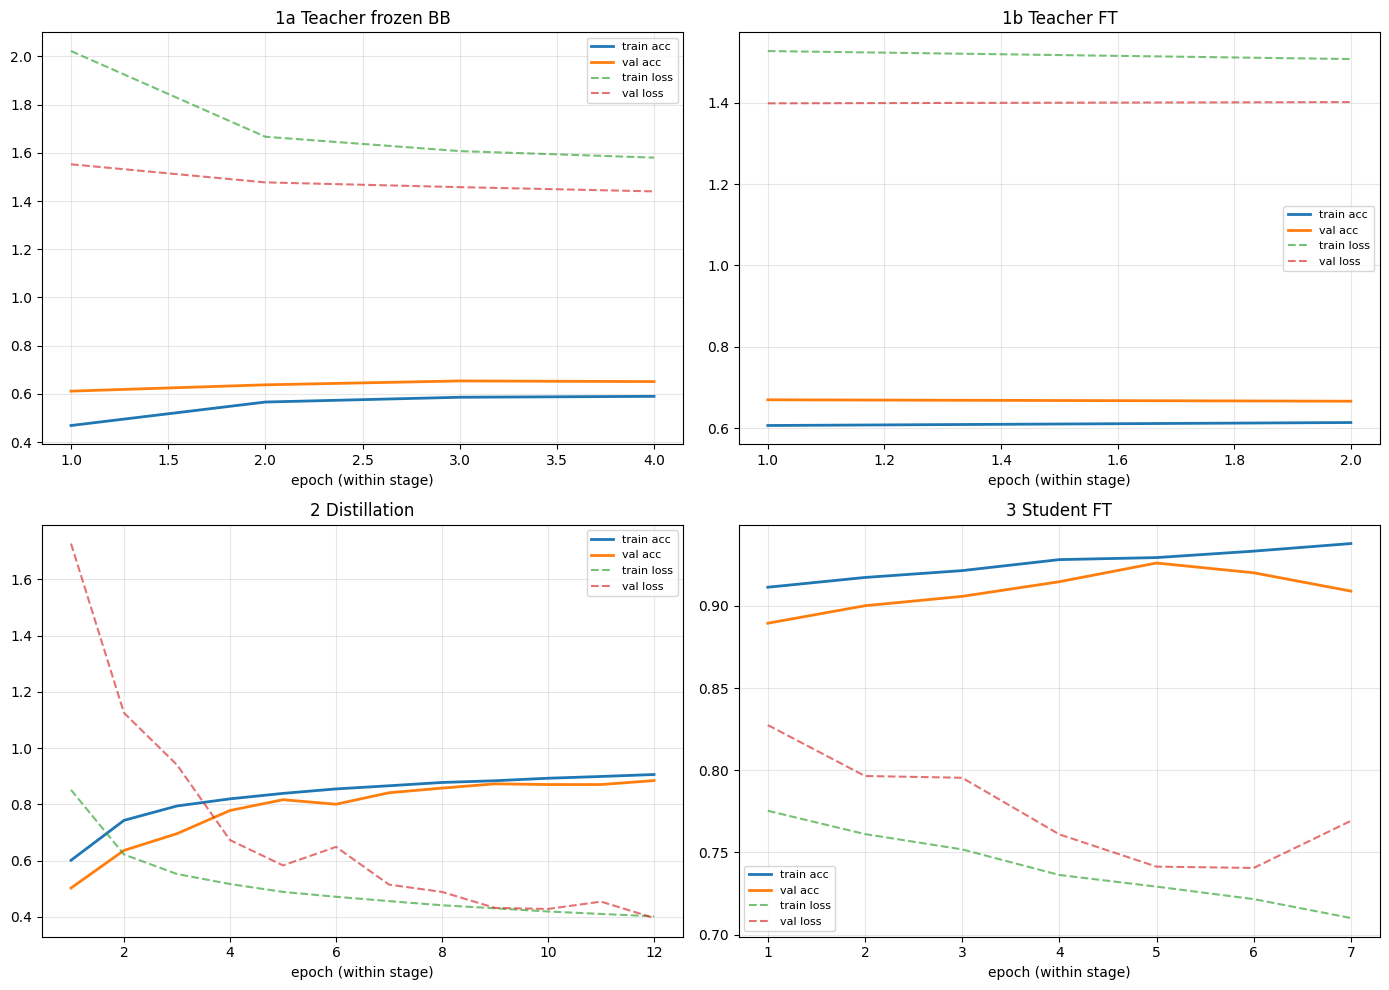


[ResourceUsage SUMMARY]
  Epochs logged: 25
  Total train time: 30710.36s
  Avg throughput: 33.38 img/s
  Peak GPU mem used: 134.7 MB
  Peak process RSS:  9044.0 MB


,epoch,duration_s,throughput_img_s,gpu_used_mb,gpu_peak_mb,proc_rss_mb,sys_ram_used_mb,sys_ram_pct,cpu_pct,lr,loss,accuracy,val_loss,val_accuracy
0,1,1972.575,20.57,82.4,2266.6,3909.7,3810.8,13.4,0.0,0.0010,2.022354,0.468476,1.552444,0.611084
1,2,1166.350,34.79,82.7,2266.6,3910.6,3785.3,13.3,37.5,0.0010,1.666698,0.565836,1.477344,0.637308
2,3,1172.758,34.60,83.0,2266.6,4193.6,4087.1,14.2,41.9,0.0010,1.607251,0.585693,1.457619,0.653389
3,4,1174.056,34.56,83.3,2266.6,4564.8,4454.3,15.4,40.5,0.0010,1.580109,0.589467,1.440072,0.650668
4,1,1205.695,33.65,83.7,2266.6,4246.7,4136.1,14.4,58.5,0.0001,1.526884,0.606290,1.398395,0.669471
5,2,1198.042,33.87,84.0,2266.6,4381.9,4276.1,14.8,75.0,0.0001,1.507197,0.613616,1.401448,0.666007
6,1,1353.195,29.99,111.2,4841.2,6676.5,6563.4,21.9,67.5,0.0001,0.851422,0.600830,1.727601,0.502227
7,2,1197.257,33.89,111.8,4841.2,7032.6,6927.9,23.1,56.1,0.0001,0.621513,0.742971,1.125153,0.636071
8,3,1190.120,34.09,112.5,4841.2,7480.3,7370.3,24.5,52.5,0.0001,0.552046,0.794123,0.940217,0.695695
9,4,1224.162,33.15,113.1,4841.2,8106.4,8020.5,26.5,74.4,0.0001,0.516439,0.819481,0.672673,0.778080


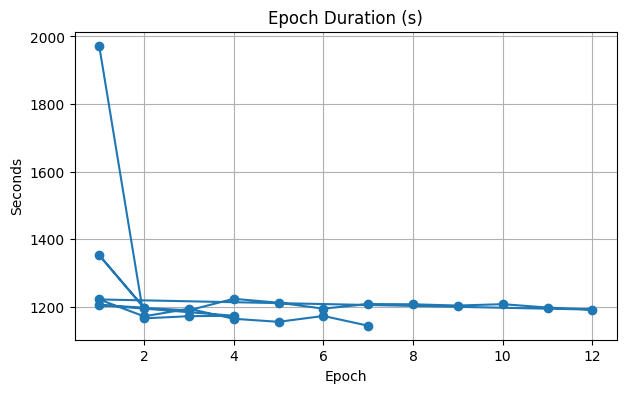

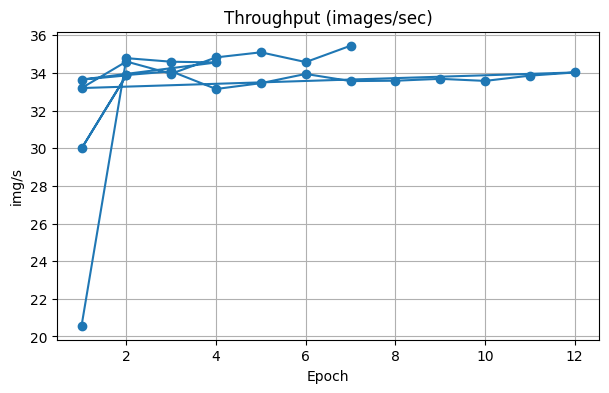

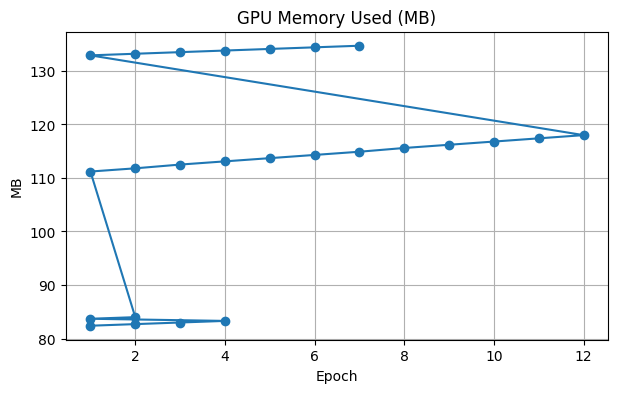

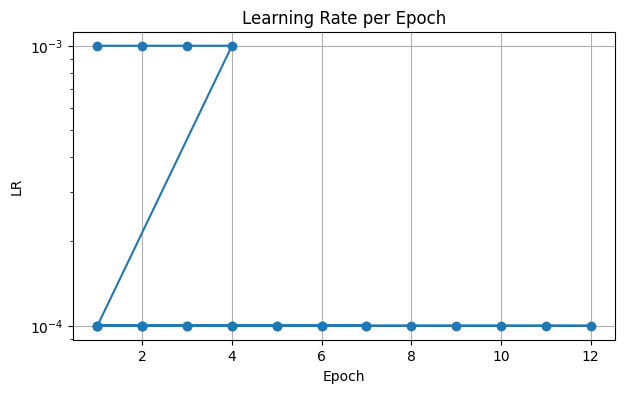

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/64 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9156 - loss: 0.7404

2026-05-05 19:54:39.468518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 19:54:39.611562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9154 - loss: 0.7413

[Test] single-pass — loss=0.7705  acc=0.9110
64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 956ms/step


2026-05-05 19:56:03.628275: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 19:56:03.766181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[Test] TTA (avg orig+hflip) acc=0.9166  (use this for reporting if higher)

Classification Report:

                                        precision    recall  f1-score   support

    Maize___Maize Cercospora Leaf Spot       0.82      0.96      0.89       164
             Maize___Maize Common Rust       0.93      0.95      0.94       190
                 Maize___Maize Healthy       0.96      0.95      0.95       205
             Maize___Maize Leaf Blight       0.86      0.83      0.85        99
               Maize___Maize Leaf Spot       0.79      0.87      0.83       125
    Maize___Maize Northern Leaf Blight       1.00      0.83      0.90       190
            Maize___Maize Streak Virus       0.88      0.87      0.88        95
          Potato___Potato Early Blight       0.99      0.97      0.98       193
               Potato___Potato Healthy       0.99      0.91      0.95       182
           Potato___Potato Late Blight       0.99      0.95      0.97       193
        Tomato___To

,precision,recall,f1-score,support
Maize___Maize Cercospora Leaf Spot,0.819,0.963,0.885,164.000
Maize___Maize Common Rust,0.933,0.947,0.940,190.000
Maize___Maize Healthy,0.960,0.946,0.953,205.000
Maize___Maize Leaf Blight,0.863,0.828,0.845,99.000
Maize___Maize Leaf Spot,0.790,0.872,0.829,125.000
Maize___Maize Northern Leaf Blight,1.000,0.826,0.905,190.000
Maize___Maize Streak Virus,0.883,0.874,0.878,95.000
Potato___Potato Early Blight,0.995,0.969,0.982,193.000
Potato___Potato Healthy,0.994,0.907,0.948,182.000
Potato___Potato Late Blight,0.995,0.948,0.971,193.000


[Metrics] Saved detailed report to: /kaggle/working/classification_report.csv


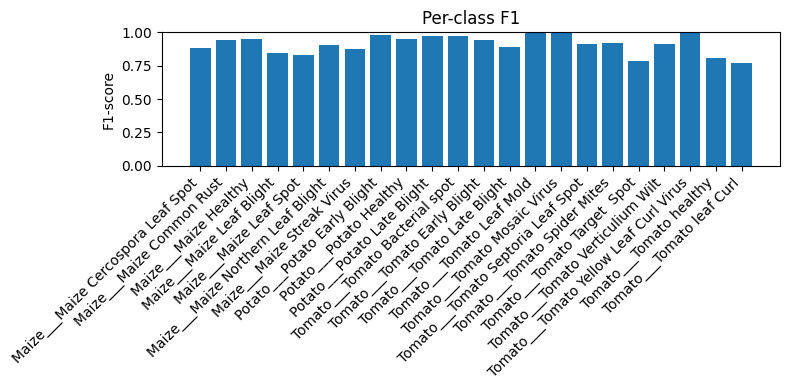

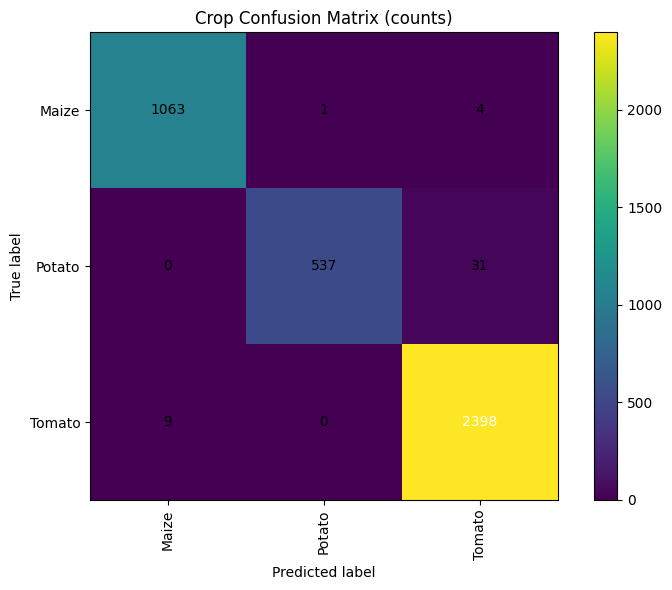

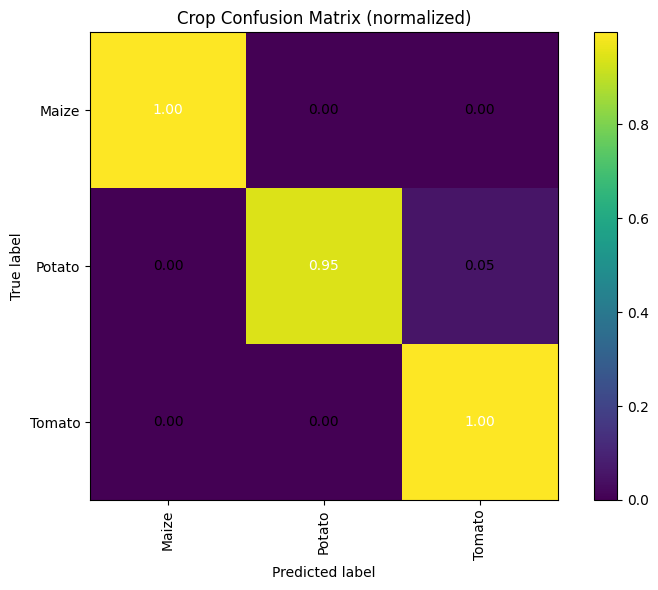

Final model saved to: /kaggle/working/models/hybrid_effnet_mobilenet_distill_final.weights.h5


In [2]:
# ============================================
# 12) Training History — accuracy at all stages + RU charts
# ============================================
import numpy as np

def _hist_series(h, key, fb=None):
    if h is None or not hasattr(h, "history"):
        return None
    d = h.history
    if key in d:
        return d[key]
    if fb and fb in d:
        return d[fb]
    return None

def print_stage_metrics(title, h):
    """Print best / final val_accuracy and train accuracy when present."""
    va = _hist_series(h, "val_accuracy", "val_acc")
    ta = _hist_series(h, "accuracy", "acc")
    print(f"\n=== {title} ===")
    if va is not None and len(va):
        print(f"  val_accuracy: best={max(va):.4f}  final={va[-1]:.4f}")
    else:
        print("  val_accuracy: (not in history)")
    if ta is not None and len(ta):
        print(f"  accuracy:     best={max(ta):.4f}  final={ta[-1]:.4f}")
    else:
        print("  accuracy:     (not in history)")

history_teacher_s1 = globals().get("history_teacher_s1", None)
history_teacher_s2 = globals().get("history_teacher_s2", None)
history_distill = globals().get("history_distill", None)
history_student_ft = globals().get("history_student_ft", None)

if all(h is None for h in [history_teacher_s1, history_teacher_s2, history_distill, history_student_ft]):
    print("[WARN] No training history found in memory.")
    print("Run the training cell first (the one that starts with setup/config and model.fit calls).")

print_stage_metrics("Phase 1a — Teacher (frozen backbone)", history_teacher_s1)
print_stage_metrics("Phase 1b — Teacher (backbone fine-tune)", history_teacher_s2)
print_stage_metrics("Phase 2 — Student distillation", history_distill)
print_stage_metrics("Phase 3 — Student (backbone fine-tune)", history_student_ft)

def plot_four_stages(histories, titles):
    """2x2 grid: each subplot is one training stage (local epochs)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, h, title in zip(axes.flatten(), histories, titles):
        if h is None:
            ax.set_title(title + " (missing)"); ax.axis("off"); continue
        d = h.history
        ta = d.get("accuracy") or d.get("acc")
        va = d.get("val_accuracy") or d.get("val_acc")
        tl = d.get("loss")
        vl = d.get("val_loss")
        n = 0
        for s in (ta, va, tl, vl):
            if s is not None:
                n = max(n, len(s))
        if n == 0:
            ax.set_title(title + " (empty)"); ax.axis("off"); continue
        ep = np.arange(1, n + 1)
        if ta is not None:
            ax.plot(ep[:len(ta)], ta, label="train acc", linewidth=2)
        if va is not None:
            ax.plot(ep[:len(va)], va, label="val acc", linewidth=2)
        if tl is not None:
            ax.plot(ep[:len(tl)], tl, "--", alpha=0.65, label="train loss")
        if vl is not None:
            ax.plot(ep[:len(vl)], vl, "--", alpha=0.65, label="val loss")
        ax.set_title(title)
        ax.set_xlabel("epoch (within stage)"); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

plot_four_stages(
    [history_teacher_s1, history_teacher_s2, history_distill, history_student_ft],
    ["1a Teacher frozen BB", "1b Teacher FT", "2 Distillation", "3 Student FT"],
)

# RU table + charts
if os.path.exists(RESOURCE_LOG_PATH):
    df = pd.read_csv(RESOURCE_LOG_PATH).replace([np.inf, -np.inf], np.nan).fillna(0)
    total_time = df["duration_s"].sum() if "duration_s" in df else np.nan
    peak_gpu = df["gpu_used_mb"].max() if "gpu_used_mb" in df and df["gpu_used_mb"].notna().any() else np.nan
    peak_rss = df["proc_rss_mb"].max() if "proc_rss_mb" in df and df["proc_rss_mb"].notna().any() else np.nan
    avg_ips  = df["throughput_img_s"].mean() if "throughput_img_s" in df and df["throughput_img_s"].notna().any() else np.nan

    print("\n[ResourceUsage SUMMARY]")
    print(f"  Epochs logged: {len(df)}")
    if 'TOTAL_EPOCHS' in globals() and len(df) != TOTAL_EPOCHS:
        print(f"  [WARN] Expected {TOTAL_EPOCHS} epochs in this run. If higher, restart kernel and run all cells once.")
    print(f"  Total train time: {total_time:.2f}s")
    print(f"  Avg throughput: {avg_ips:.2f} img/s")
    print(f"  Peak GPU mem used: {peak_gpu} MB")
    print(f"  Peak process RSS:  {peak_rss} MB")

    from IPython.display import display
    display(df)

    if "duration_s" in df:
        plt.figure(figsize=(7,4)); plt.plot(df["epoch"], df["duration_s"], marker="o")
        plt.title("Epoch Duration (s)"); plt.xlabel("Epoch"); plt.ylabel("Seconds"); plt.grid(True); plt.show()
    if "throughput_img_s" in df:
        plt.figure(figsize=(7,4)); plt.plot(df["epoch"], df["throughput_img_s"], marker="o")
        plt.title("Throughput (images/sec)"); plt.xlabel("Epoch"); plt.ylabel("img/s"); plt.grid(True); plt.show()
    if "gpu_used_mb" in df and df["gpu_used_mb"].notna().any():
        plt.figure(figsize=(7,4)); plt.plot(df["epoch"], df["gpu_used_mb"], marker="o")
        plt.title("GPU Memory Used (MB)"); plt.xlabel("Epoch"); plt.ylabel("MB"); plt.grid(True); plt.show()
    if "lr" in df and df["lr"].notna().any():
        plt.figure(figsize=(7,4)); plt.plot(df["epoch"], df["lr"], marker="o")
        plt.title("Learning Rate per Epoch"); plt.xlabel("Epoch"); plt.ylabel("LR"); plt.yscale("log"); plt.grid(True); plt.show()
else:
    print("[ResourceUsage] Log not found at", RESOURCE_LOG_PATH)

# ============================================
# 13) Evaluate on test set (no-augment + TTA for higher reported accuracy)
# ============================================
if 'model' not in globals() or 'test_flow' not in globals():
    print("[WARN] Missing `model` or `test_flow` in memory. Run training/data cell first.")
else:
    pass

def predict_with_tta(mdl, flow, verbose=1):
    """Average softmax over original and horizontal flip (no extra training time)."""
    flow.reset()
    p0 = mdl.predict(flow, verbose=verbose)
    flow.reset()
    chunks = []
    seen = 0
    for bx, _ in flow:
        flipped = np.flip(bx, axis=2).copy()
        chunks.append(mdl.predict(flipped, verbose=0))
        seen += len(bx)
        if seen >= flow.samples:
            break
    p1 = np.concatenate(chunks, axis=0)[:flow.samples]
    return (p0 + p1) / 2.0

test_loss, test_acc = model.evaluate(test_flow, verbose=1)
print(f"\n[Test] single-pass — loss={test_loss:.4f}  acc={test_acc:.4f}")

y_true = test_flow.classes
y_prob = predict_with_tta(model, test_flow, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
tta_acc = float(np.mean(y_pred == y_true))
print(f"[Test] TTA (avg orig+hflip) acc={tta_acc:.4f}  (use this for reporting if higher)")

# Predictions & metrics (from TTA probabilities)
class_names = list(test_flow.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

from sklearn.metrics import classification_report as cr_dict
report_dict = cr_dict(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose().replace([np.inf, -np.inf], np.nan).fillna(0)

from IPython.display import display
display(report_df.round(3))
report_df.to_csv(CLASSIF_REPORT_CSV, index=True)
print(f"[Metrics] Saved detailed report to: {CLASSIF_REPORT_CSV}")

plt.figure(figsize=(8,4))
plt.bar(class_names, report_df.loc[class_names, "f1-score"])
plt.ylim(0, 1); plt.ylabel("F1-score"); plt.title("Per-class F1")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

# Confusion Matrices
def plot_conf_mat(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm_disp = cm.astype(np.float64)
        cm_disp = cm_disp / (cm_disp.sum(axis=1, keepdims=True) + 1e-12)
        fmt = ".2f"
    else:
        cm_disp = cm.astype(np.int64)
        fmt = "d"
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_disp, interpolation='nearest')
    ax.set_title(title); plt.colorbar(im, ax=ax)
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_xticklabels(classes, rotation=90)
    ax.set_yticks(ticks); ax.set_yticklabels(classes)
    ax.set_ylabel('True label'); ax.set_xlabel('Predicted label')
    vmin, vmax = np.nanmin(cm_disp), np.nanmax(cm_disp)
    thresh = (vmin + vmax) / 2.0
    for i in range(cm_disp.shape[0]):
        for j in range(cm_disp.shape[1]):
            val = cm_disp[i, j]
            ax.text(j, i, format(val, fmt),
                    ha="center", va="center",
                    color="white" if val > thresh else "black", fontsize=10)
    plt.tight_layout(); plt.show()

def to_crop_label(lbl):
    # Labels are expected as "Crop___Disease". Fallback keeps old behavior safe.
    return lbl.split("___")[0] if "___" in lbl else lbl

idx_to_class = {v: k for k, v in test_flow.class_indices.items()}
y_true_crop = [to_crop_label(idx_to_class[int(i)]) for i in y_true]
y_pred_crop = [to_crop_label(idx_to_class[int(i)]) for i in y_pred]

crop_names = sorted(set(y_true_crop) | set(y_pred_crop))
cm_crop = confusion_matrix(y_true_crop, y_pred_crop, labels=crop_names)

plot_conf_mat(cm_crop, crop_names, normalize=False, title="Crop Confusion Matrix (counts)")
plot_conf_mat(cm_crop, crop_names, normalize=True,  title="Crop Confusion Matrix (normalized)")

# ============================================
# 14) Save final model
# ============================================
os.makedirs(os.path.dirname(FINAL_MODEL_PATH), exist_ok=True)
model.save_weights(FINAL_MODEL_PATH)
print(f"Final model saved to: {FINAL_MODEL_PATH}")
